In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
from typing import Dict, Tuple
import json

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


import pandas as pd


# Осмотр данных


In [3]:
df = pd.read_csv('/content/train.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

# Создание DataFrame для хранения признаков
df_features = pd.DataFrame()

Размер датасета: 872 строк, 20 столбцов


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype 
---  ------                                                                --------------  ----- 
 0   Пол                                                                   872 non-null    object
 1   Дата рождения                                                         872 non-null    object
 2   Онкологический диагноз                                                872 non-null    object
 3   Дата постановки онкологического диагноза / начала первичного лечения  796 non-null    object
 4   Дата удаления первичного очага                                        543 non-null    object
 5   Дата развития МГМ                                                     787 non-null    object
 6   Активирующие мутации                                                  338 non-null    object
 7   Дата про

In [5]:
df.describe()

,Число РХ процедур на ГН,Индекс Карновского,Число очагов в ГМ
count,872.000000,872.000000,872.000000
mean,1.378440,78.463303,5.497706
std,0.735452,9.250986,5.327182
min,1.000000,40.000000,1.000000
25%,1.000000,70.000000,2.000000
50%,1.000000,80.000000,4.000000
75%,2.000000,80.000000,7.000000
max,6.000000,100.000000,37.000000


In [6]:
df.describe(include='object')

,Пол,Дата рождения,Онкологический диагноз,Дата постановки онкологического диагноза / начала первичного лечения,Дата удаления первичного очага,Дата развития МГМ,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Дата 1-ой РХ,Суммарный объем очагов,Объем максимального очага,Экстракраниальные метастазы,Лекарственное лечение,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия
count,872,872,872,796,543,787,338,779,823,872,872,872,559,595,679,679,680
unique,4,843,5,323,250,419,2,105,206,764,664,540,2,3,167,357,4
top,Ж,15.01.1947,РМЖ,01.12.2008,не удален,01.10.2012,нет,нет,нет,03.08.2015,"1,27","2,80",есть,Химиотерапия,нет,нет,ДМ
freq,492,3,263,34,91,12,172,665,606,3,5,10,501,367,510,290,279


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент (%)': missing_pct})
missing_df[missing_df['Пропуски'] > 0].sort_values('Процент (%)', ascending=False)

,Пропуски,Процент (%)
Активирующие мутации,534,61.2
Дата удаления первичного очага,329,37.7
Экстракраниальные метастазы,313,35.9
Лекарственное лечение,277,31.8
Локальный рецидив,193,22.1
Дистантные метастазы,193,22.1
Интракраниальная прогрессия,192,22.0
Дата проведения ОВГМ,93,10.7
Дата развития МГМ,85,9.7
Дата постановки онкологического диагноза / начала первичного лечения,76,8.7


#Преобразование данных


In [8]:
date_cols = [
    'Дата рождения',
    'Дата постановки онкологического диагноза / начала первичного лечения',
    'Дата удаления первичного очага',
    'Дата развития МГМ',
    'Дата проведения ОВГМ',
    'Дата операции на ГМ',
    'Дата 1-ой РХ',
    'Локальный рецидив',
    'Дистантные метастазы',
]

for col in date_cols:
    # Заменяем «нет», «не удален», «#REF!» и пустые строки на NaN перед парсингом
    df[col] = df[col].astype(str).replace(['нет', 'не удален', '#REF!', '', 'nan', '<NA>'], np.nan)
    df[col] = pd.to_datetime(df[col], format='%d.%m.%Y', errors='coerce')



# Преобразуем числовые столбцы, которые могли быть прочитаны как object
numeric_cols = ['Суммарный объем очагов', 'Объем максимального очага','Индекс Карновского', 'Число очагов в ГМ', 'Число РХ процедур на ГН']

for col in numeric_cols:
    if df[col].dtype in ('object', 'str', 'string'):
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')



#Новые признаки

### Возраст пациента

Считаем как разницу между датой 1-ой РХ и датой рождения

In [9]:

df['Возраст_на_СРТ'] = ((df['Дата 1-ой РХ'] - df['Дата рождения']).dt.days / 365.25).round(1)

print("Статистика по возрасту на момент СРТ:")
print(df['Возраст_на_СРТ'].describe())

Статистика по возрасту на момент СРТ:
count    872.000000
mean      55.126835
std       11.254268
min       23.000000
25%       48.675000
50%       55.950000
75%       63.000000
max       88.900000
Name: Возраст_на_СРТ, dtype: float64


### Время реагирования


In [10]:
df['Время_реагирования'] = (
    df['Дата 1-ой РХ'] - df['Дата развития МГМ']).dt.days

print("Статистика по времени реагирования (дни):")
print(df['Время_реагирования'].describe())

Статистика по времени реагирования (дни):
count     786.000000
mean      102.270992
std       348.899181
min     -3634.000000
25%        19.000000
50%        34.000000
75%       101.000000
max      2138.000000
Name: Время_реагирования, dtype: float64


## Время метастазирования
отрицательные значения здесь допустимы,что может показывать,
что МГМ были обнаружены раньше, чем был установлен первичный онкологический диагноз

In [11]:
df['Время_метастазирования'] = (
    df['Дата развития МГМ'] - df['Дата постановки онкологического диагноза / начала первичного лечения']
).dt.days

print("Статистика по времени метастазирования (дни):")
print(df['Время_метастазирования'].describe())

Статистика по времени метастазирования (дни):
count     763.000000
mean      984.879423
std      1266.892339
min       -76.000000
25%       151.000000
50%       541.000000
75%      1277.500000
max      8310.000000
Name: Время_метастазирования, dtype: float64


#Исправление данных

In [12]:
df = df.drop(['Активирующие мутации'],axis=1).copy()
#отдельно парсим пол
df['Пол'] = df['Пол'].str.upper()

df = df[df['Время_реагирования'] >= 0].copy()

#Визуализация


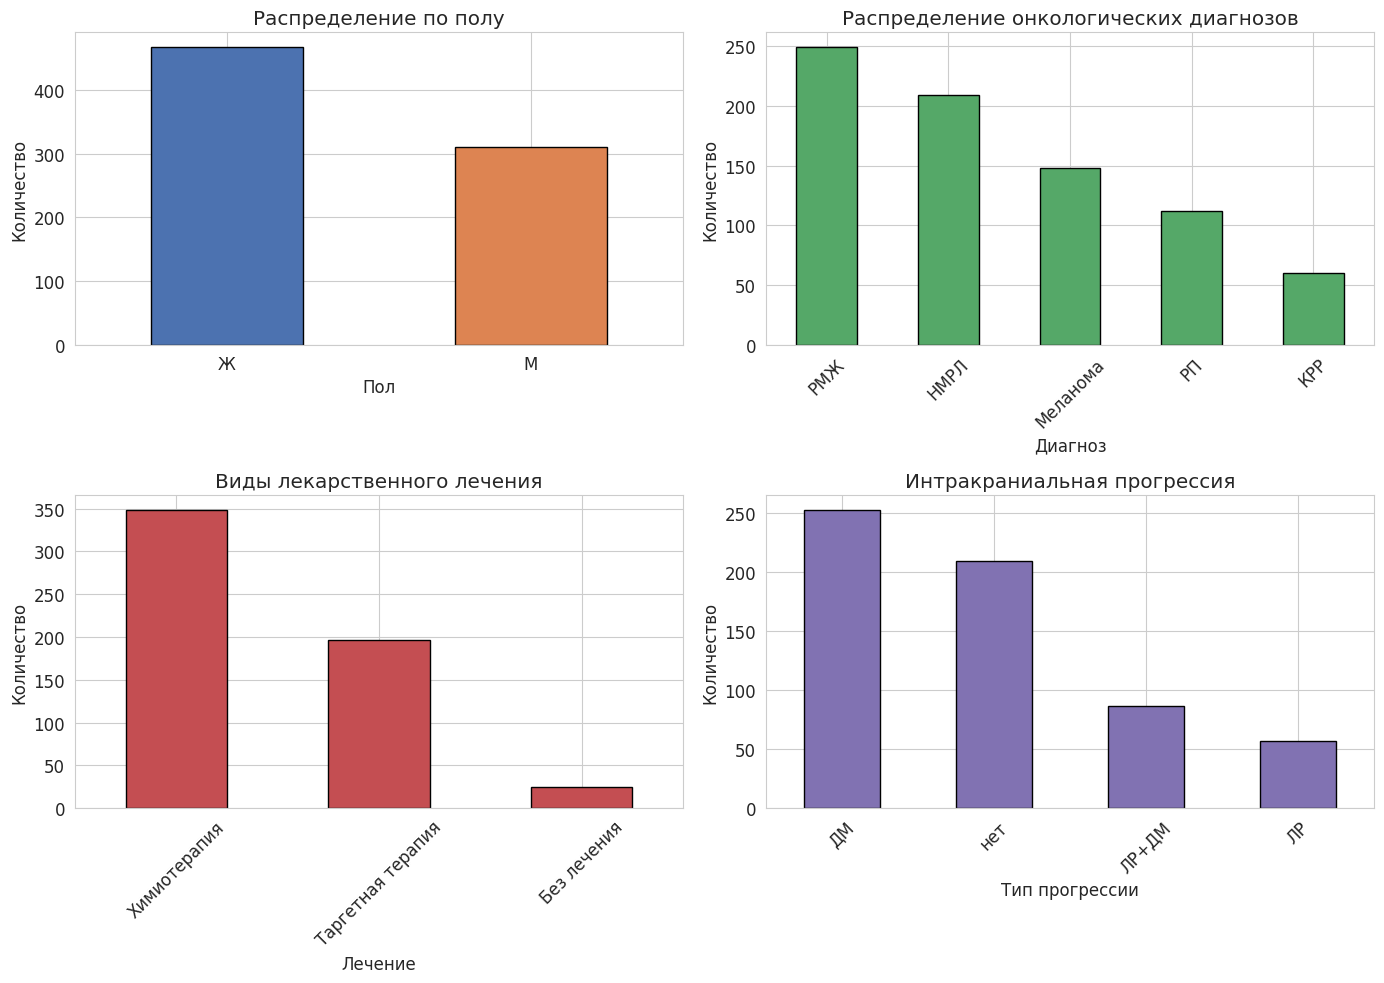

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Пол
df['Пол'].value_counts().plot.bar(ax=axes[0, 0], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0, 0].set_title('Распределение по полу')
axes[0, 0].set_xlabel('Пол')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].tick_params(axis='x', rotation=0)

# Онкологический диагноз
df['Онкологический диагноз'].value_counts().plot.bar(ax=axes[0, 1], color='#55A868', edgecolor='black')
axes[0, 1].set_title('Распределение онкологических диагнозов')
axes[0, 1].set_xlabel('Диагноз')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].tick_params(axis='x', rotation=45)

# Лекарственное лечение
df['Лекарственное лечение'].value_counts().plot.bar(ax=axes[1, 0], color='#C44E52', edgecolor='black')
axes[1, 0].set_title('Виды лекарственного лечения')
axes[1, 0].set_xlabel('Лечение')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].tick_params(axis='x', rotation=45)

# Интракраниальная прогрессия
df['Интракраниальная прогрессия'].value_counts().plot.bar(ax=axes[1, 1], color='#8172B2', edgecolor='black')
axes[1, 1].set_title('Интракраниальная прогрессия')
axes[1, 1].set_xlabel('Тип прогрессии')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Количество пропущенных значений: 0


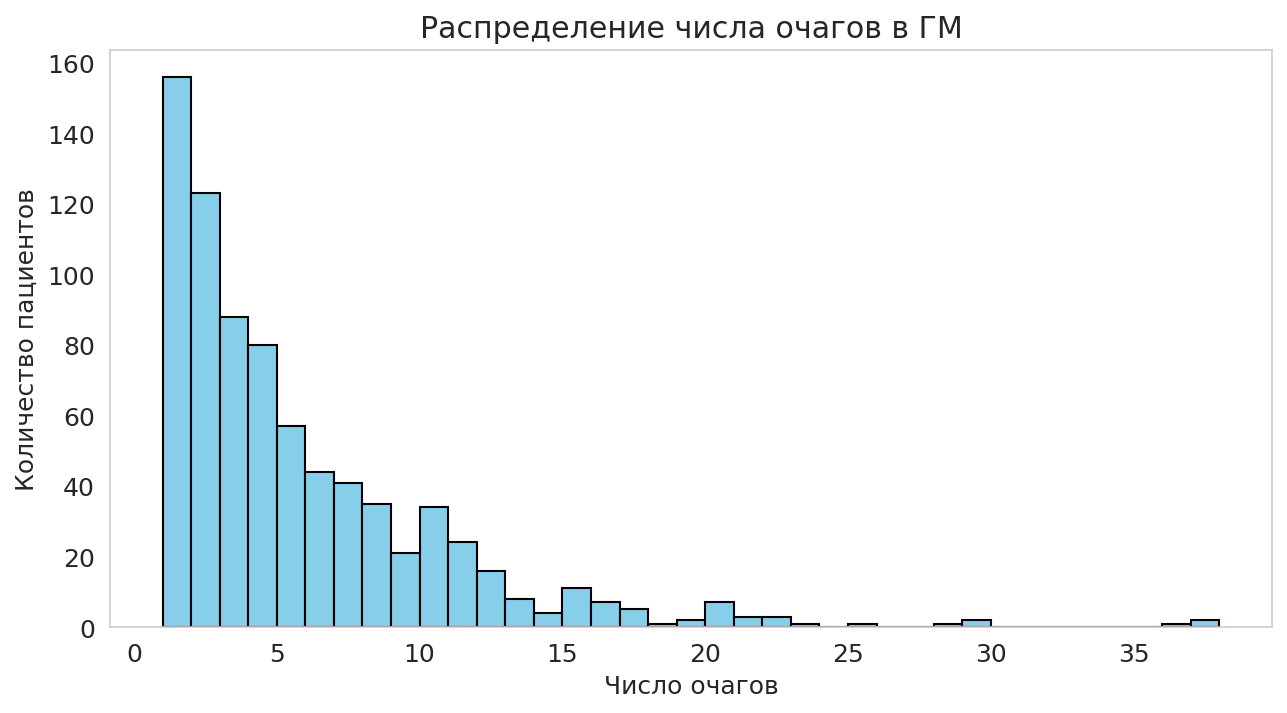

In [14]:
missing_lesions = df['Число очагов в ГМ'].isna().sum()
print(f"Количество пропущенных значений: {missing_lesions}")

df['Число очагов в ГМ'] = pd.to_numeric(df['Число очагов в ГМ'])

plt.figure(figsize=(10, 5), dpi=150)
plt.hist(df['Число очагов в ГМ'],
         bins=range(int(df['Число очагов в ГМ'].min()), int(df['Число очагов в ГМ'].max()) + 2),
         color='skyblue', edgecolor='black')
plt.title('Распределение числа очагов в ГМ')
plt.xlabel('Число очагов')
plt.ylabel('Количество пациентов')
plt.grid(False)
plt.savefig('fig_lesions.png', dpi=150, bbox_inches='tight')
plt.show()

Количество пропущенных значений: 0


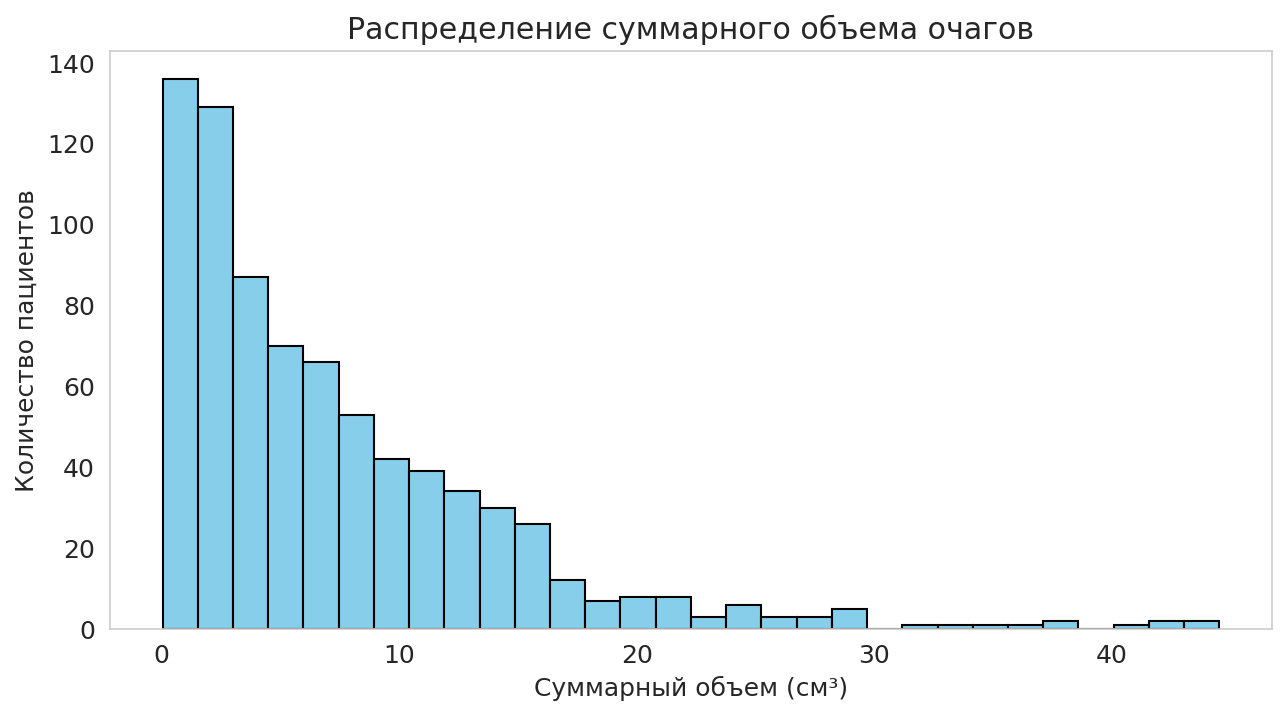

In [15]:
missing_total_volume = df['Суммарный объем очагов'].isna().sum()
print(f"Количество пропущенных значений: {missing_total_volume}")

df['Суммарный объем очагов'] = pd.to_numeric(
    df['Суммарный объем очагов'].astype(str).str.replace(',', '.'), errors='coerce'
)

plt.figure(figsize=(10, 5), dpi=150)
plt.hist(df['Суммарный объем очагов'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение суммарного объема очагов')
plt.xlabel('Суммарный объем (см³)')
plt.ylabel('Количество пациентов')
plt.grid(False)
plt.show()

Количество пропущенных значений: 0


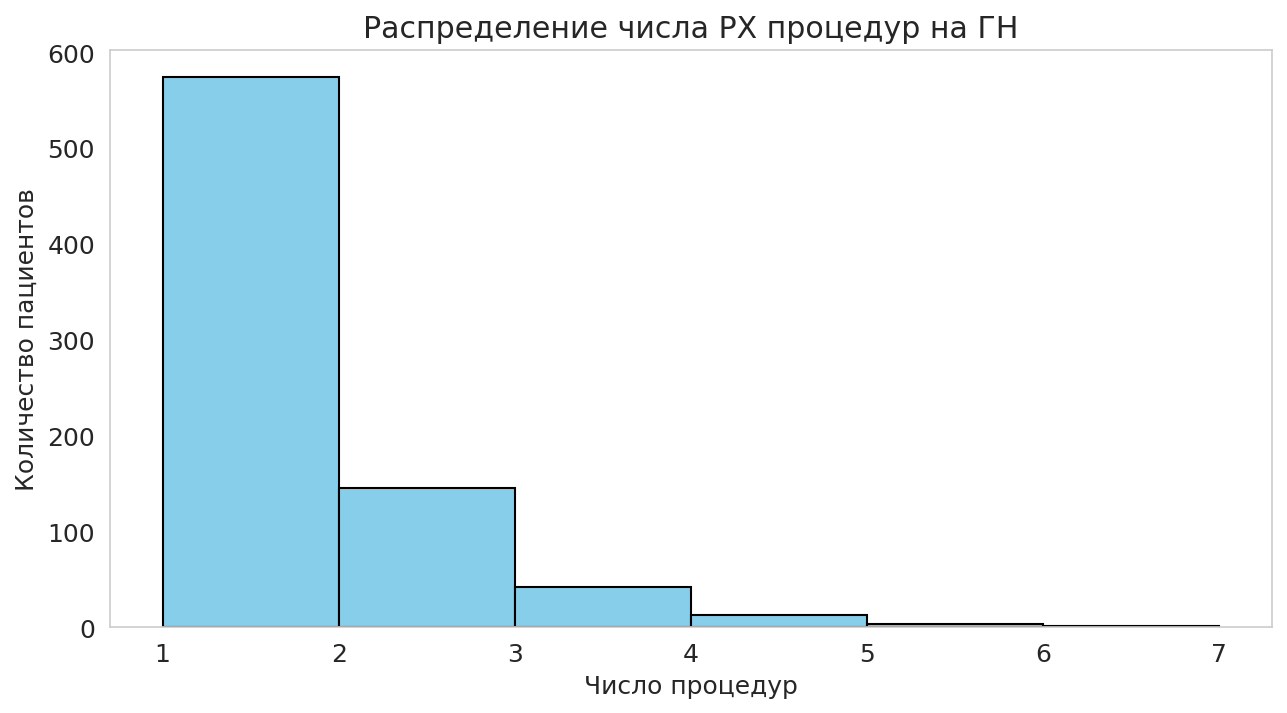

In [16]:
missing_fractions = df['Число РХ процедур на ГН'].isna().sum()
print(f"Количество пропущенных значений: {missing_fractions}")

df['Число РХ процедур на ГН'] = pd.to_numeric(df['Число РХ процедур на ГН'])
plt.figure(figsize=(10, 5), dpi=150)
plt.hist(df['Число РХ процедур на ГН'],
         bins=range(int(df['Число РХ процедур на ГН'].min()), int(df['Число РХ процедур на ГН'].max()) + 2),
         color='skyblue', edgecolor='black')
plt.title('Распределение числа РХ процедур на ГН')
plt.xlabel('Число процедур')
plt.ylabel('Количество пациентов')
plt.grid(False)
plt.show()

Количество пропущенных значений: 0


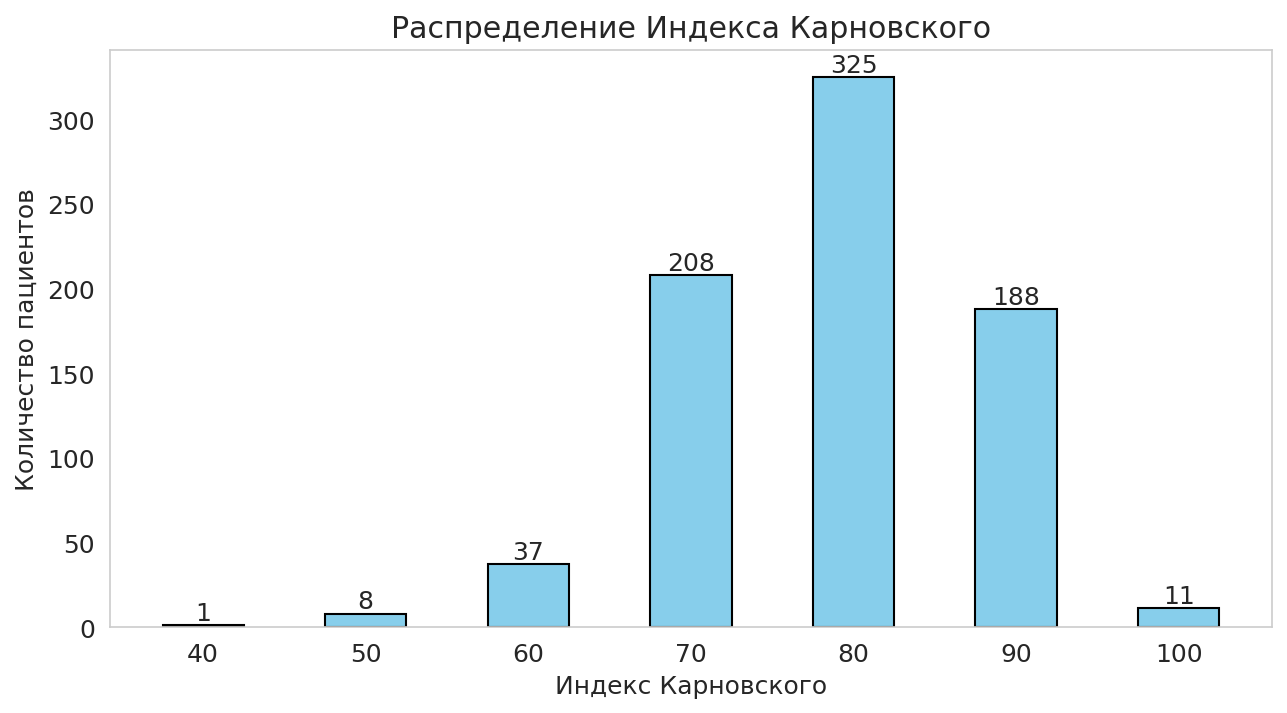

In [17]:
missing_karnofsky = df['Индекс Карновского'].isna().sum()
print(f"Количество пропущенных значений: {missing_karnofsky}")

df['Индекс Карновского'] = pd.to_numeric(df['Индекс Карновского'])
plt.figure(figsize=(10, 5), dpi=150)
counts_kps = df['Индекс Карновского'].value_counts().sort_index()
bars = plt.bar(counts_kps.index, counts_kps.values, color='skyblue', edgecolor='black', width=5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')
plt.title('Распределение Индекса Карновского')
plt.xlabel('Индекс Карновского')
plt.ylabel('Количество пациентов')
plt.xticks(counts_kps.index)
plt.grid(False)
plt.show()

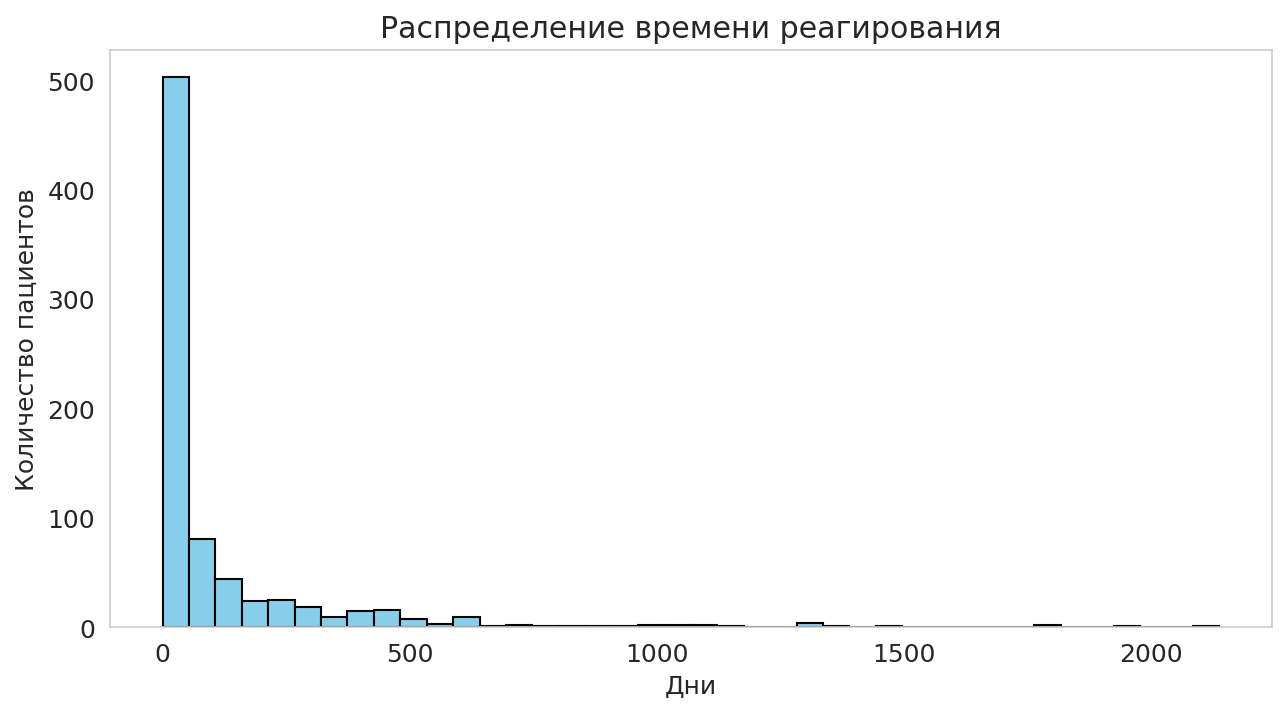

In [18]:
plt.figure(figsize=(10, 5), dpi=150)
plt.hist(df['Время_реагирования'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('Распределение времени реагирования')
plt.xlabel('Дни')
plt.ylabel('Количество пациентов')
plt.grid(False)
plt.show()

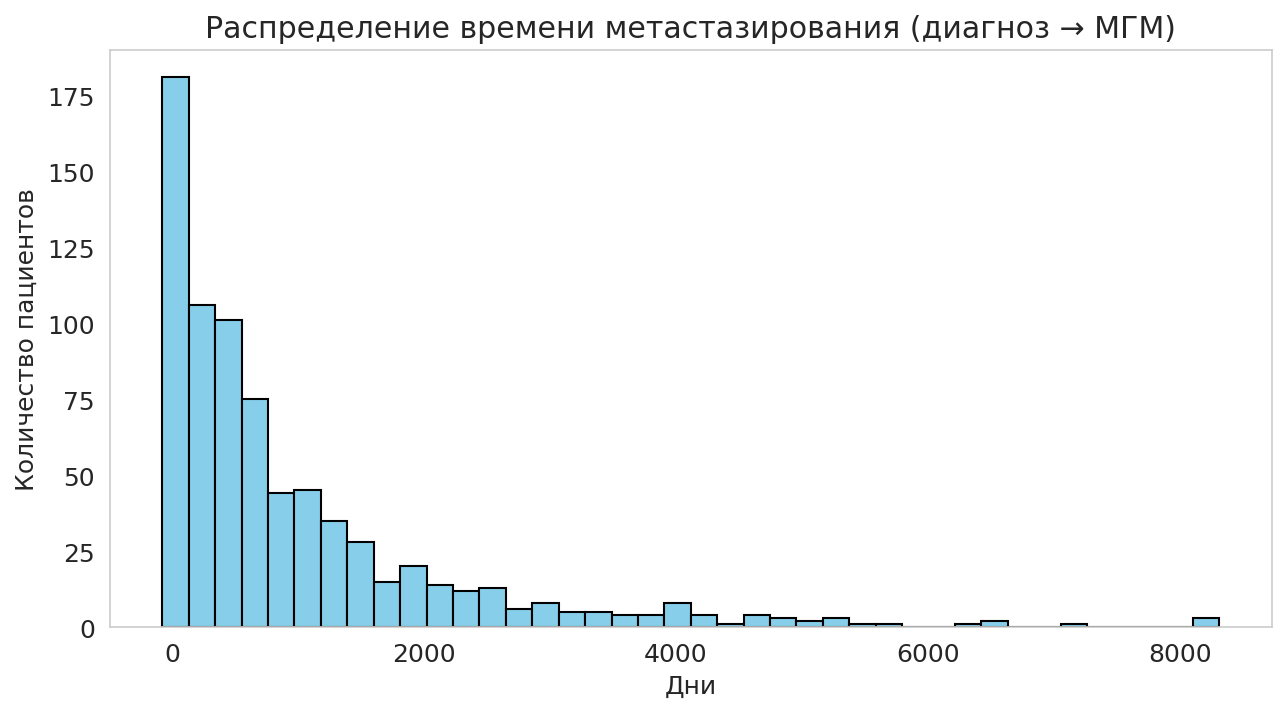

In [19]:
plt.figure(figsize=(10, 5), dpi=150)
plt.hist(df['Время_метастазирования'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('Распределение времени метастазирования (диагноз → МГМ)')
plt.xlabel('Дни')
plt.ylabel('Количество пациентов')
plt.grid(False)
plt.savefig('fig_metastasis_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def map_binary(x):
    if pd.isna(x):
        return np.nan
    elif str(x).strip().lower() == 'нет':
        return 0
    else:
        return 1


df['ОВГМ'] = df['Дата проведения ОВГМ'].apply(map_binary)
df['Операция'] = df['Дата операции на ГМ'].apply(map_binary)
df['ЭКМ'] = df['Экстракраниальные метастазы'].apply(map_binary)
df_features = df[['Интракраниальная прогрессия', 'Пол', 'Онкологический диагноз', 'Число очагов в ГМ', 'Суммарный объем очагов', 'Число РХ процедур на ГН', 'Индекс Карновского', 'Возраст_на_СРТ', 'Время_реагирования', 'Время_метастазирования', 'Лекарственное лечение', 'ОВГМ', 'Операция', 'ЭКМ']]
df_features = df_features.dropna()
df_features = df_features.reset_index(drop=True)

# Домашее задание_5

Реализация метода универсальной нормализации и демонстрация

Mode = median. Sample params (column 'with_outliers'):
 {
  "q1": -0.6757458539120312,
  "q3": 0.6707762936408492,
  "iqr": 1.3465221475528804,
  "lower": -2.695529075241352,
  "upper": 2.69055951497017,
  "median": -0.031299192860860026,
  "min_clip": -2.695529075241352,
  "max_clip": 2.69055951497017
}


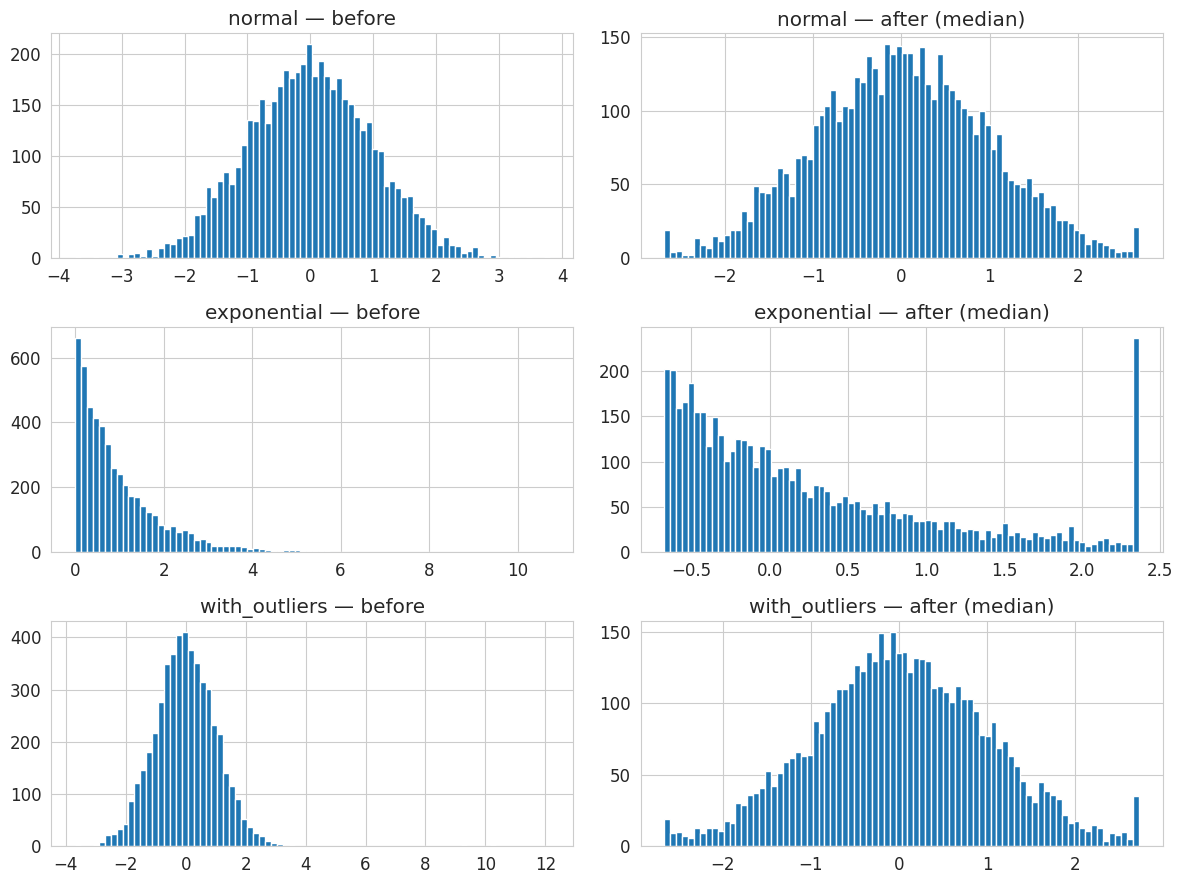

Mode = range. Sample params (column 'with_outliers'):
 {
  "q1": -0.6757458539120312,
  "q3": 0.6707762936408492,
  "iqr": 1.3465221475528804,
  "lower": -2.695529075241352,
  "upper": 2.69055951497017,
  "median": -0.031299192860860026,
  "min_clip": -2.695529075241352,
  "max_clip": 2.69055951497017
}


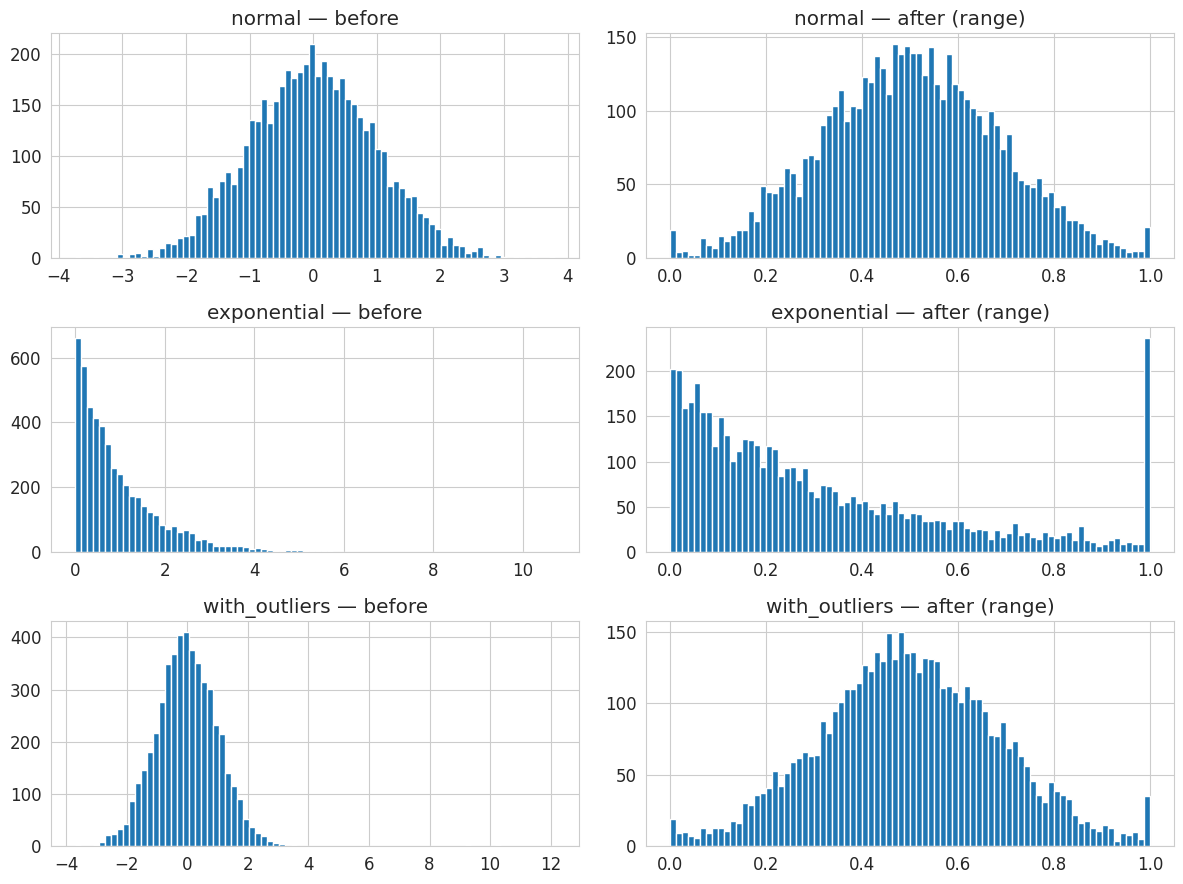

Mode = both. Sample params (column 'with_outliers'):
 {
  "q1": -0.6757458539120312,
  "q3": 0.6707762936408492,
  "iqr": 1.3465221475528804,
  "lower": -2.695529075241352,
  "upper": 2.69055951497017,
  "median": -0.031299192860860026,
  "min_clip": -2.695529075241352,
  "max_clip": 2.69055951497017
}


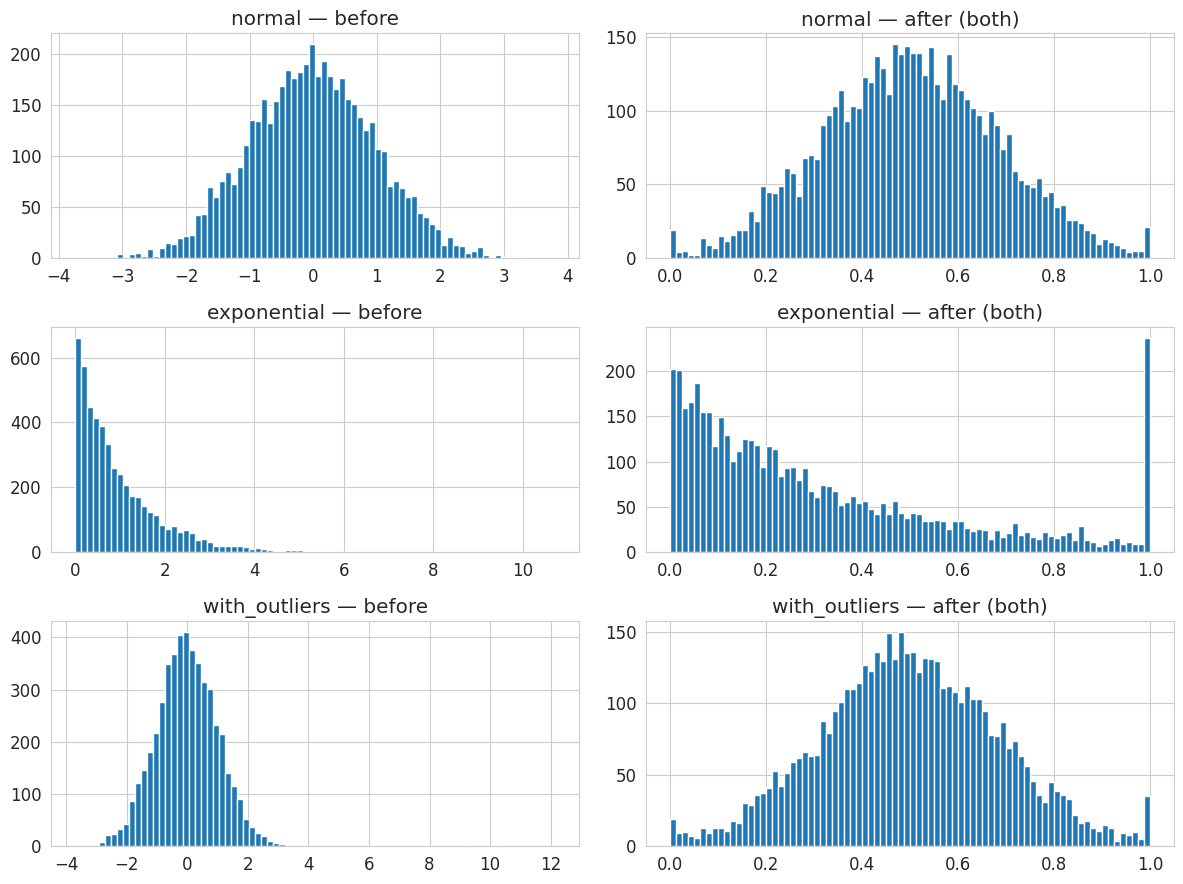

In [21]:


class UniversalNormalizer:
    """
    режимы:
      - 'median'  : центрирование относительно медианы после коррекции выбросов
      - 'range'   : приведение скорректированного интервала к [0,1] (min->0, max->1)
      - 'both'    : сначала центрирование по медиане (результат может быть не в [0,1]),
    """

    def __init__(self, mode: str = 'both', iqr_factor: float = 1.5):
        assert mode in ('median', 'range', 'both'), "mode must be 'median', 'range' or 'both'"
        self.mode = mode
        self.iqr_factor = float(iqr_factor)
        self.params: Dict[str, Dict[str, float]] = {}

    def _compute_params_series(self, s: pd.Series) -> Dict[str, float]:
        nonan = s.dropna()
        q1 = nonan.quantile(0.25)
        q3 = nonan.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - self.iqr_factor * iqr
        upper = q3 + self.iqr_factor * iqr
        median = nonan.median()
        clipped = nonan.clip(lower=lower, upper=upper)
        min_clip = float(clipped.min()) if len(clipped) > 0 else float(lower)
        max_clip = float(clipped.max()) if len(clipped) > 0 else float(upper)
        return {
            'q1': float(q1), 'q3': float(q3), 'iqr': float(iqr),
            'lower': float(lower), 'upper': float(upper),
            'median': float(median),
            'min_clip': min_clip, 'max_clip': max_clip
        }

    def fit(self, X: pd.DataFrame):
        if isinstance(X, pd.Series):
            X = X.to_frame('col')
        for col in X.select_dtypes(include=[np.number]).columns:
            self.params[col] = self._compute_params_series(X[col])
        return self

    def _transform_series(self, s: pd.Series) -> pd.Series:
        p = self.params.get(s.name, None)
        if p is None:
            return s.copy()

        clipped = s.clip(lower=p['lower'], upper=p['upper'])

        if self.mode == 'median':
            # центрирование относительно медианы
            return clipped - p['median']

        if self.mode == 'range':
            denom = (p['max_clip'] - p['min_clip'])
            if denom == 0:
                return clipped - p['min_clip']  # degenerate case
            return (clipped - p['min_clip']) / denom

        # 1) центрируем относительно медианы, но делаем масштабирование по скорректированному интервалу
        centered = clipped - p['median']
        min_c = p['min_clip'] - p['median']
        max_c = p['max_clip'] - p['median']
        denom = (max_c - min_c)
        if denom == 0:
            return centered - min_c
        return (centered - min_c) / denom

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if isinstance(X, pd.Series):
            return self._transform_series(X)
        X_out = X.copy()
        for col in X.select_dtypes(include=[np.number]).columns:
            X_out[col] = self._transform_series(X[col])
        return X_out

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(X).transform(X)

    def get_params(self) -> Dict[str, Dict[str, float]]:
        return self.params

# Демонстрация
def demo_synthetic():
    np.random.seed(0)
    n = 5000
    normal = np.random.normal(loc=0, scale=1, size=n)
    exponential = np.random.exponential(scale=1.0, size=n)
    with_outliers = np.concatenate([np.random.normal(0,1,n-10), np.random.normal(10,1,10)])

    df = pd.DataFrame({
        'normal': normal,
        'exponential': exponential,
        'with_outliers': with_outliers
    })

    for mode in ('median','range','both'):
        norm = UniversalNormalizer(mode=mode, iqr_factor=1.5)
        df_norm = norm.fit_transform(df)
        print(f"Mode = {mode}. Sample params (column 'with_outliers'):\n",
              json.dumps(norm.get_params()['with_outliers'], indent=2))
        # Plot before/after for each column
        fig, axes = plt.subplots(3, 2, figsize=(12, 9))
        for i, col in enumerate(df.columns):
            axes[i,0].hist(df[col], bins=80)
            axes[i,0].set_title(f"{col} — before")
            axes[i,1].hist(df_norm[col], bins=80)
            axes[i,1].set_title(f"{col} — after ({mode})")
        plt.tight_layout()
        plt.show()

demo_synthetic()

## Применение к данным

One-hot result shape: (778, 19)
Итоговый shape: (778, 30)


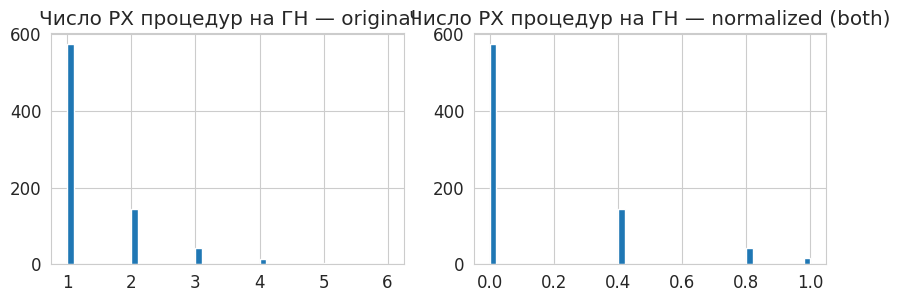

Stats for Число РХ процедур на ГН:
 {
  "orig": {
    "min": 1.0,
    "q1": 1.0,
    "median": 1.0,
    "q3": 2.0,
    "max": 6.0,
    "IQR": 1.0
  },
  "normalized": {
    "min": 0.0,
    "q1": 0.0,
    "median": 0.0,
    "q3": 0.4,
    "max": 1.0,
    "IQR": 0.4
  }
}


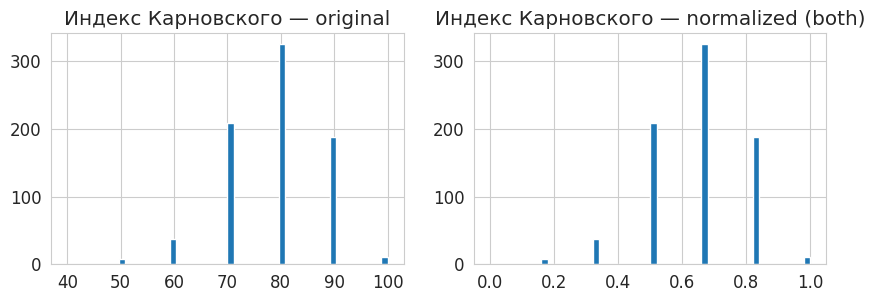

Stats for Индекс Карновского:
 {
  "orig": {
    "min": 40.0,
    "q1": 70.0,
    "median": 80.0,
    "q3": 90.0,
    "max": 100.0,
    "IQR": 20.0
  },
  "normalized": {
    "min": 0.0,
    "q1": 0.5,
    "median": 0.6666666666666666,
    "q3": 0.8333333333333334,
    "max": 1.0,
    "IQR": 0.33333333333333337
  }
}


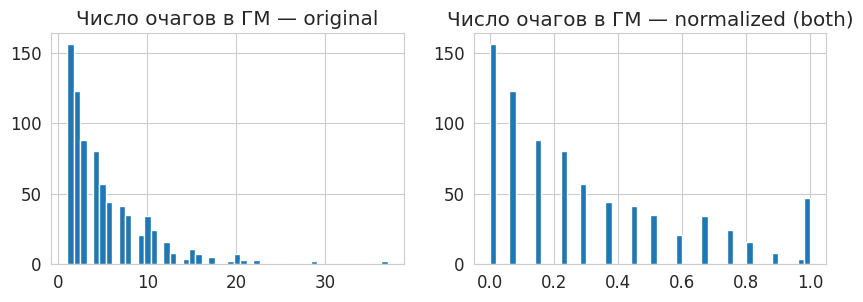

Stats for Число очагов в ГМ:
 {
  "orig": {
    "min": 1.0,
    "q1": 2.0,
    "median": 4.0,
    "q3": 7.0,
    "max": 37.0,
    "IQR": 5.0
  },
  "normalized": {
    "min": 0.0,
    "q1": 0.07407407407407407,
    "median": 0.2222222222222222,
    "q3": 0.4444444444444444,
    "max": 1.0,
    "IQR": 0.37037037037037035
  }
}


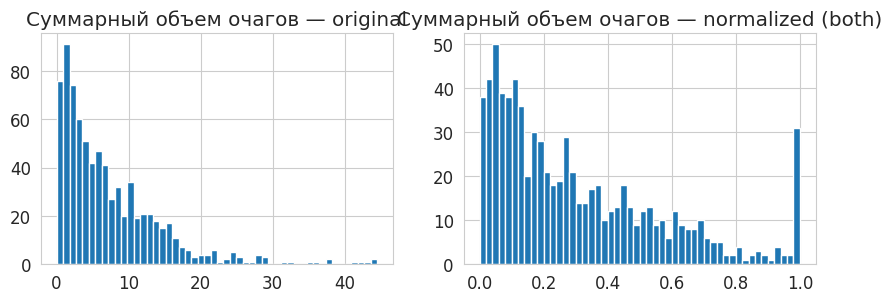

Stats for Суммарный объем очагов:
 {
  "orig": {
    "min": 0.04,
    "q1": 2.145,
    "median": 5.195,
    "q3": 10.425,
    "max": 44.52,
    "IQR": 8.280000000000001
  },
  "normalized": {
    "min": 0.0,
    "q1": 0.09230431922823941,
    "median": 0.2260469195351896,
    "q3": 0.4553825915369436,
    "max": 1.0,
    "IQR": 0.3630782723087042
  }
}


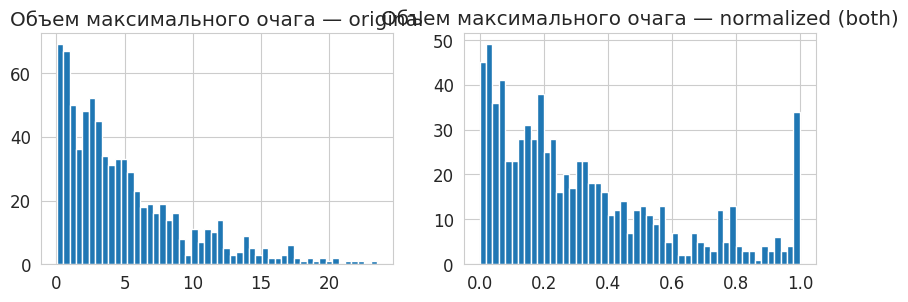

Stats for Объем максимального очага:
 {
  "orig": {
    "min": 0.04,
    "q1": 1.5425,
    "median": 3.585,
    "q3": 6.930000000000001,
    "max": 23.51,
    "IQR": 5.387500000000001
  },
  "normalized": {
    "min": 0.0,
    "q1": 0.1003590214577941,
    "median": 0.23678717541955413,
    "q3": 0.4602154128746765,
    "max": 1.0,
    "IQR": 0.3598563914168824
  }
}


In [22]:
import os, glob
from IPython.display import display


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()


df_cat = pd.get_dummies(df[cat_cols].astype(str), drop_first=False) if cat_cols else pd.DataFrame(index=df.index)
print("One-hot result shape:", df_cat.shape)

# Нормализация числовых столбцов
norm = UniversalNormalizer(mode='both', iqr_factor=1.5)
df_num = df[numeric_cols].copy()
df_num_norm = norm.fit_transform(df_num)

df_processed = pd.concat([df_num_norm, df_cat], axis=1)

print("Итоговый shape:", df_processed.shape)



to_report = numeric_cols[:5]
for col in to_report:
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    axes[0].hist(df[col].dropna(), bins=50)
    axes[0].set_title(f"{col} — original")
    axes[1].hist(df_num_norm[col].dropna(), bins=50)
    axes[1].set_title(f"{col} — normalized ({norm.mode})")
    plt.show()

    # статистика
    orig = df[col].dropna()
    new = df_num_norm[col].dropna()
    stats = {
        'orig': {
            'min': float(orig.min()), 'q1': float(orig.quantile(0.25)), 'median': float(orig.median()),
            'q3': float(orig.quantile(0.75)), 'max': float(orig.max()), 'IQR': float(orig.quantile(0.75)-orig.quantile(0.25))
        },
        'normalized': {
            'min': float(new.min()), 'q1': float(new.quantile(0.25)), 'median': float(new.median()),
            'q3': float(new.quantile(0.75)), 'max': float(new.max()), 'IQR': float(new.quantile(0.75)-new.quantile(0.25))
        }
    }
    print(f"Stats for {col}:\n", json.dumps(stats, indent=2))
